In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot-Stil global festlegen
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# Output-Ordner für gespeicherte Grafiken
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def save_fig(fig, name):
    """Speichert jede Grafik zusätzlich als PNG für die Präsentation."""
    fig.savefig(f"{OUTPUT_DIR}/{name}.png", dpi=150, bbox_inches="tight")

In [2]:
df_raw = pd.read_csv("../data/price_clean.csv")
print("Rohdaten-Shape:", df_raw.shape)
df_raw.head()

Rohdaten-Shape: (5055, 20)


,obj_regio1,obj_newlyConst,obj_yearConstructed,obj_firingTypes,obj_cellar,obj_houseNumber,obj_livingSpace,geo_krs,obj_condition,obj_street,geo_plz,obj_noRooms,obj_telekomInternetProductAvailable,obj_barrierFree,obj_regio3,obj_livingSpaceRange,obj_telekomUploadSpeed,obj_telekomDownloadSpeed,obj_purchasePrice,obj_purchasePrice_per_qm
0,Niedersachsen,n,2013.0,gas,n,NaN,170.0,Verden_Kreis,well_kept,NaN,28832.0,6.0,True,n,Achim,5.0,40.0,100.0,549000.0,3229.411765
1,Niedersachsen,n,1909.0,oil,n,NaN,170.0,Hannover_Kreis,well_kept,NaN,30900.0,6.0,True,n,Wedemark,5.0,2.4,16.0,460000.0,2705.882353
2,Niedersachsen,n,1969.0,district_heating,y,NaN,116.0,Celle_Kreis,well_kept,NaN,29353.0,6.0,True,n,other,2.0,10.0,50.0,148500.0,1280.172414
3,Niedersachsen,y,2020.0,NaN,n,NaN,133.0,Helmstedt_Kreis,first_time_use,NaN,38364.0,4.0,True,n,Schöningen,3.0,40.0,100.0,248400.0,1867.669173
4,Niedersachsen,n,2000.0,district_heating,y,NaN,136.0,Wolfsburg,well_kept,NaN,38446.0,5.0,True,y,other,3.0,2.4,16.0,369000.0,2713.235294


In [4]:
df = df_raw.copy()

# 1. حذف العمود الثابت
df = df.drop(columns=["obj_regio1"])

# 2. تحديد عمود الـ Data Leakage لعدم استخدامه في الـ ML لاحقاً
LEAKAGE_COL = "obj_purchasePrice_per_qm"

# 3. معالجة القيم غير المنطقية
n_before = len(df)
df = df[df["obj_livingSpace"] > 0]
print(f"Entfernt wegen livingSpace <= 0: {n_before - len(df)} Zeilen")

n_before = len(df)
df = df[df["obj_purchasePrice"] >= 5000]
print(f"Entfernt wegen purchasePrice < 5000 EUR: {n_before - len(df)} Zeilen")

# التأكد من التخلص من قيم الـ Infinity
assert not np.isinf(df[LEAKAGE_COL]).any(), "Es gibt noch inf-Werte!"
print("Bereinigte Daten-Shape:", df.shape)

Entfernt wegen livingSpace <= 0: 5 Zeilen
Entfernt wegen purchasePrice < 5000 EUR: 18 Zeilen
Bereinigte Daten-Shape: (5032, 19)


                                     fehlend  prozent
obj_houseNumber                         4564     90.7
obj_street                              4564     90.7
obj_condition                           1552     30.8
obj_telekomUploadSpeed                   981     19.5
obj_telekomDownloadSpeed                 981     19.5
obj_firingTypes                          797     15.8
obj_telekomInternetProductAvailable      324      6.4


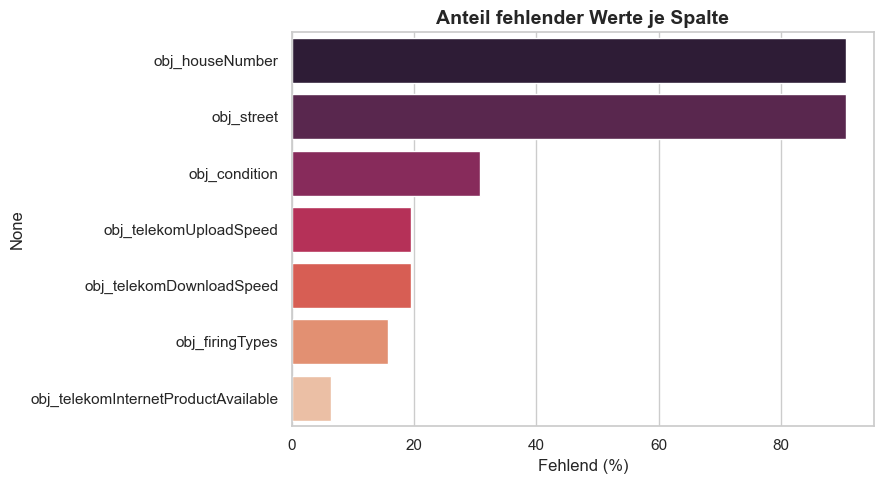

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({"fehlend": missing, "prozent": missing_pct})
missing_table = missing_table[missing_table["fehlend"] > 0]
print(missing_table)

# رسم بياني للقيم المفقودة
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=missing_table["prozent"],
    y=missing_table.index,
    hue=missing_table.index,
    ax=ax,
    palette="rocket",
    legend=False,
)
ax.set_title("Anteil fehlender Werte je Spalte")
ax.set_xlabel("Fehlend (%)")
plt.tight_layout()
save_fig(fig, "01_fehlende_werte")
plt.show()

# معالجة النقص بالتعويض أو الحذف
df = df.drop(columns=["obj_houseNumber", "obj_street"])
df["obj_firingTypes"] = df["obj_firingTypes"].fillna("unknown")
df["obj_condition"] = df["obj_condition"].fillna("unknown")
df["obj_hasInternetData"] = df["obj_telekomUploadSpeed"].notna().astype(int)
df["obj_telekomUploadSpeed"] = df["obj_telekomUploadSpeed"].fillna(0)
df["obj_telekomDownloadSpeed"] = df["obj_telekomDownloadSpeed"].fillna(0)
df["obj_telekomInternetProductAvailable"] = (
    df["obj_telekomInternetProductAvailable"].fillna("unknown").astype(str)
)

In [6]:
def group_firing_type(value):
    value = str(value).lower()
    if value == "unknown":
        return "unknown"
    if "gas" in value:
        return "gas"
    if "oil" in value:
        return "oil"
    if "district_heating" in value or "local_heating" in value:
        return "fernwaerme"
    if "solar" in value or "geothermal" in value or "environmental" in value or "pellet" in value or "wood" in value:
        return "erneuerbar"
    if "electricity" in value:
        return "strom"
    return "sonstige"


df["firingType_grouped"] = df["obj_firingTypes"].apply(group_firing_type)
print(df["firingType_grouped"].value_counts())

# حفظ الداتا النظيفة المستعدة للتحليل الإحصائي
df.to_csv("price_cleaned_for_analysis.csv", index=False)

firingType_grouped
gas           3034
oil            850
unknown        797
strom          138
erneuerbar     135
fernwaerme      69
sonstige         9
Name: count, dtype: int64


In [7]:
numeric_cols = [
    "obj_purchasePrice",
    "obj_purchasePrice_per_qm",
    "obj_livingSpace",
    "obj_noRooms",
    "obj_yearConstructed",
]
desc_table = df[numeric_cols].describe().T
desc_table["median"] = df[numeric_cols].median()
desc_table["variance"] = df[numeric_cols].var()
desc_table["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(
    0.25
)
desc_table["skew"] = df[numeric_cols].skew()
print(desc_table.round(2))

# حساب عدد الـ Outliers بالـ IQR
def count_iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()


for col in [
    "obj_purchasePrice",
    "obj_livingSpace",
    "obj_purchasePrice_per_qm",
    "obj_noRooms",
]:
    n_out = count_iqr_outliers(df[col])
    print(f"{col}: {n_out} Ausreißer ({n_out/len(df)*100:.1f}%) nach 1.5*IQR-Regel")

                           count       mean        std       min        25%  \
obj_purchasePrice         5032.0  370492.21  313186.06  10000.00  216625.00   
obj_purchasePrice_per_qm  5032.0    2012.99    1120.52     30.56    1287.46   
obj_livingSpace           5032.0     196.67     133.89     30.00     125.00   
obj_noRooms               5032.0       6.66       3.86      1.00       4.00   
obj_yearConstructed       5032.0    1964.11      53.92   1496.00    1952.00   

                               50%        75%         max    median  \
obj_purchasePrice         307750.0  429000.00  4900000.00  307750.0   
obj_purchasePrice_per_qm    1893.8    2572.59    27267.71    1893.8   
obj_livingSpace              162.0     228.25     3000.00     162.0   
obj_noRooms                    6.0       8.00      100.00       6.0   
obj_yearConstructed         1973.0    1999.00     2021.00    1973.0   

                              variance        IQR  skew  
obj_purchasePrice         9.808551e+10  

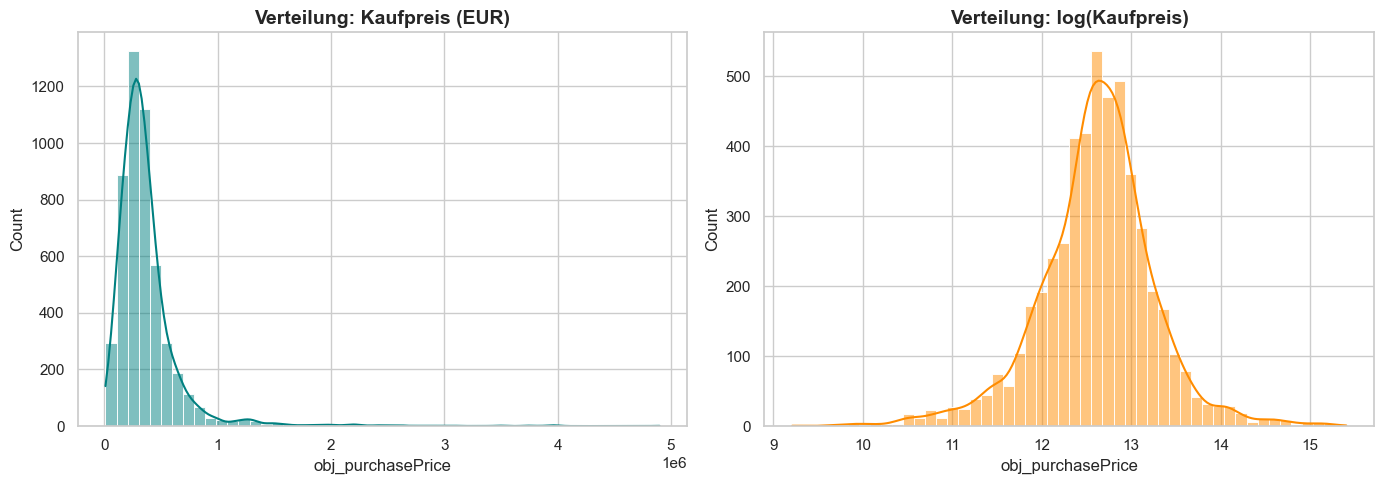

In [8]:
# رسم توزيع السعر العادي والـ LogPrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["obj_purchasePrice"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Verteilung: Kaufpreis (EUR)")

sns.histplot(
    np.log1p(df["obj_purchasePrice"]),
    bins=50,
    kde=True,
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Verteilung: log(Kaufpreis)")
plt.tight_layout()
save_fig(fig, "02_verteilung_kaufpreis")
plt.show()

# رسم الـ Boxplots لرؤية الـ Outliers بشكل مرئي وعلاقة المتغيرات بالأسعار
# (يمكنك تشغيل بقية رسومات الـ Boxplot والـ Barplot الموجودة في كودك هنا)

In [9]:
# 1. اختبار فرضية: هل أسعار المتر في العقارات الجديدة تختلف عن القديمة؟
group_new = df.loc[df["obj_newlyConst"] == "y", "obj_purchasePrice_per_qm"]
group_old = df.loc[df["obj_newlyConst"] == "n", "obj_purchasePrice_per_qm"]

# نختبر الاعتدالية أولاً بشيربيو-ويلك
shapiro_new = stats.shapiro(
    group_new.sample(min(500, len(group_new)), random_state=42)
)
print(f"Shapiro-Wilk P-Value: {shapiro_new.pvalue:.4f}")

# بما أن التوزيع ليس طبيعي (p < 0.05)، نستخدم اختبار Mann-Whitney-U البديل غير المعلمي لـ t-test
u_stat, p_value = stats.mannwhitneyu(group_new, group_old, alternative="two-sided")
print(f"Mann-Whitney-U-Test p-value: {p_value:.6f}")

Shapiro-Wilk P-Value: 0.0000
Mann-Whitney-U-Test p-value: 0.000000


In [10]:
model_results = pd.DataFrame(
    {
        "Modell": [
            "Linear Regression (Phase 1)",
            "Linear Regression (Phase 2)",
            "Linear Regression (Phase 3)",
            "Linear Regression (Phase 4)",
            "Random Forest (Phase 1)",
            "Random Forest (Phase 2)",
            "XGBoost (Final)",
        ],
        "RMSE": [None, None, None, None, None, None, None],
        "MAE": [None, None, None, None, None, None, None],
        "R2": [None, None, None, None, None, None, None],
    }
)
print(model_results)

                        Modell  RMSE   MAE    R2
0  Linear Regression (Phase 1)  None  None  None
1  Linear Regression (Phase 2)  None  None  None
2  Linear Regression (Phase 3)  None  None  None
3  Linear Regression (Phase 4)  None  None  None
4      Random Forest (Phase 1)  None  None  None
5      Random Forest (Phase 2)  None  None  None
6              XGBoost (Final)  None  None  None



Datenqualität & Fehlende Werte

In [2]:
import pandas as pd
import numpy as np

# 1. تحميل البيانات الأساسية
df_raw = pd.read_csv("../data/price_clean.csv")
print(f"📊 أبعاد البيانات الأولية (Rohdaten-Shape): {df_raw.shape}")

# 2. حساب القيم المفقودة ونسبتها المئوية
missing_counts = df_raw.isnull().sum()
missing_percentages = (df_raw.isnull().sum() / len(df_raw)) * 100

missing_table = pd.DataFrame({
    'Fehlende Werte (Count)': missing_counts,
    'Prozent (%)': missing_percentages
}).sort_values(by='Fehlende Werte (Count)', ascending=False)

# عرض الأعمدة التي تحتوي على قيم مفقودة فقط
print("\n🔍 تقييم القيم المفقودة في الأعمدة:")
print(missing_table[missing_table['Fehlende Werte (Count)'] > 0].round(2))

📊 أبعاد البيانات الأولية (Rohdaten-Shape): (5055, 20)

🔍 تقييم القيم المفقودة في الأعمدة:
                                     Fehlende Werte (Count)  Prozent (%)
obj_street                                             4583        90.66
obj_houseNumber                                        4583        90.66
obj_condition                                          1558        30.82
obj_telekomDownloadSpeed                                983        19.45
obj_telekomUploadSpeed                                  983        19.45
obj_firingTypes                                         799        15.81
obj_telekomInternetProductAvailable                     326         6.45


Data Cleaning

In [3]:
df = df_raw.copy()

# أ. حذف الأعمدة الثابتة والتي تحتوي على نقص هائل (> 90%)
df = df.drop(columns=["obj_regio1", "obj_houseNumber", "obj_street"], errors='ignore')

# ب. معالجة الأسطر غير المنطقية (المساحة 0 أو السعر شبه المجاني)
df = df[df["obj_livingSpace"] > 0]
df = df[df["obj_purchasePrice"] >= 5000]

# ج. تعويض القيم المفقودة للمتغيرات النصية لتجنب خسارة الأسطر
df["obj_condition"] = df["obj_condition"].fillna("unknown")
df["obj_firingTypes"] = df["obj_firingTypes"].fillna("unknown")

# د. تعويض سرعات الإنترنت المفقودة بـ 0 (اعتبار الخدمة غير متوفرة)
df["obj_telekomUploadSpeed"] = df["obj_telekomUploadSpeed"].fillna(0)
df["obj_telekomDownloadSpeed"] = df["obj_telekomDownloadSpeed"].fillna(0)

print(f"✅ الأبعاد بعد التنظيف والمعالجة (Cleaned Shape): {df.shape}")

✅ الأبعاد بعد التنظيف والمعالجة (Cleaned Shape): (5032, 17)


🧱 الخطوة 3: حساب المقاييس الإحصائية (Lage- und Streuungsmaße)

In [4]:
# تحديد المتغيرات الرقمية الأساسية المستهدفة
numeric_cols = ["obj_purchasePrice", "obj_livingSpace", "obj_noRooms", "obj_yearConstructed"]

# حساب الإحصاء الوصفي الأساسي وتحويله لجدول منظم
desc_stats = df[numeric_cols].describe().T

# إضافة المقاييس الإضافية المطلوبة كأعمدة جديدة
desc_stats["median (50%)"] = df[numeric_cols].median()
desc_stats["variance"] = df[numeric_cols].var()
desc_stats["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc_stats["skewness (الالتواء)"] = df[numeric_cols].skew()

print("📊 الجدول الإحصائي الشامل للمتغيرات الرقمية:")
print(desc_stats[["mean", "median (50%)", "std", "variance", "IQR", "skewness (الالتواء)"]].round(2))

📊 الجدول الإحصائي الشامل للمتغيرات الرقمية:
                          mean  median (50%)        std      variance  \
obj_purchasePrice    370492.21      307750.0  313186.06  9.808551e+10   
obj_livingSpace         196.67         162.0     133.89  1.792670e+04   
obj_noRooms               6.66           6.0       3.86  1.492000e+01   
obj_yearConstructed    1964.11        1973.0      53.92  2.907370e+03   

                           IQR  skewness (الالتواء)  
obj_purchasePrice    212375.00                 5.21  
obj_livingSpace         103.25                 6.64  
obj_noRooms               4.00                 5.36  
obj_yearConstructed      47.00                -2.66  


🧱 الخطوة 4: تحديد القيم المتطرفة علمياً (Outlier Identification via IQR)

In [5]:
print("🚨 تحليل القيم المتطرفة (Outliers) بناءً على قاعدة 1.5 * IQR:")

for col in ["obj_purchasePrice", "obj_livingSpace", "obj_noRooms"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # عزل الأسطر التي خارج الحدود
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    print(f"\n🔹 المتغير: '{col}'")
    print(f"   -> الحدود المعتمدة: الدنيا = {lower_bound:.1f} | العليا = {upper_bound:.1f}")
    print(f"   -> عدد القيم المتطرفة: {len(outliers)} عقاراً ({outlier_pct:.2f}%)")

🚨 تحليل القيم المتطرفة (Outliers) بناءً على قاعدة 1.5 * IQR:

🔹 المتغير: 'obj_purchasePrice'
   -> الحدود المعتمدة: الدنيا = -101937.5 | العليا = 747562.5
   -> عدد القيم المتطرفة: 300 عقاراً (5.96%)

🔹 المتغير: 'obj_livingSpace'
   -> الحدود المعتمدة: الدنيا = -29.9 | العليا = 383.1
   -> عدد القيم المتطرفة: 287 عقاراً (5.70%)

🔹 المتغير: 'obj_noRooms'
   -> الحدود المعتمدة: الدنيا = -2.0 | العليا = 14.0
   -> عدد القيم المتطرفة: 188 عقاراً (3.74%)


📌 1️⃣ خطوة فصل البيانات بناءً على النوع (Data Type Separation):
🔹 المتغيرات الرقمية المستهدفة: ['obj_purchasePrice', 'obj_livingSpace', 'obj_yearConstructed', 'obj_noRooms', 'obj_telekomUploadSpeed', 'obj_telekomDownloadSpeed']
🔹 المتغيرات النوعية المستهدفة: ['geo_krs', 'obj_condition', 'obj_firingTypes']
----------------------------------------------------------------------
📊 2️⃣ حساب قوة الارتباط للمتغيرات الرقمية باستخدام معامل بيرسون (Pearson Correlation):

🏆 ترتيب المتغيرات الرقمية حسب قوة ارتباط بيرسون مع السعر (Target):
obj_purchasePrice           1.0000
obj_livingSpace             0.4925
obj_noRooms                 0.3745
obj_yearConstructed         0.0686
obj_telekomDownloadSpeed    0.0621
obj_telekomUploadSpeed      0.0603
Name: obj_purchasePrice, dtype: float64
----------------------------------------------------------------------
📈 3️⃣ رسم مصفوفة الارتباط (Correlation Heatmap) للعرض أمام المشرفين:


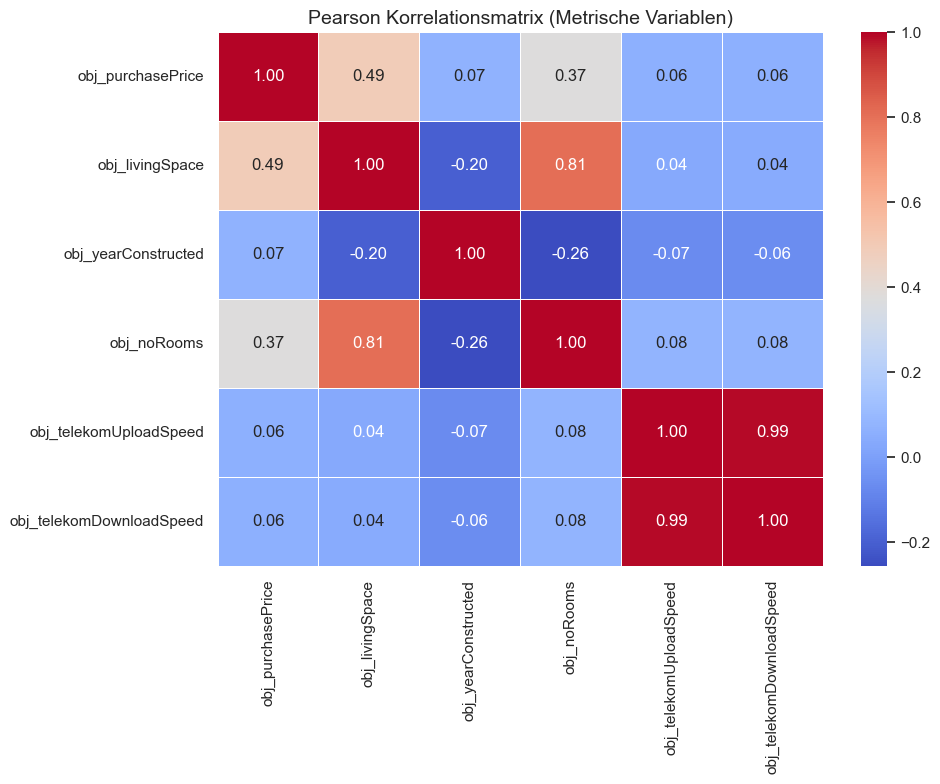

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تحميل البيانات المنظفة
df = pd.read_csv("../data/price_clean.csv")
target_variable = "obj_purchasePrice"

print("📌 1️⃣ خطوة فصل البيانات بناءً على النوع (Data Type Separation):")

# فصل الأعمدة الرقمية (Metrische Variablen)
numeric_features = ['obj_purchasePrice', 'obj_livingSpace', 'obj_yearConstructed', 
                    'obj_noRooms', 'obj_telekomUploadSpeed', 'obj_telekomDownloadSpeed']

# فصل الأعمدة النوعية/النصية (Kategoriale Variablen)
categorical_features = ['geo_krs', 'obj_condition', 'obj_firingTypes']

print(f"🔹 المتغيرات الرقمية المستهدفة: {numeric_features}")
print(f"🔹 المتغيرات النوعية المستهدفة: {categorical_features}")
print("-" * 70)

print("📊 2️⃣ حساب قوة الارتباط للمتغيرات الرقمية باستخدام معامل بيرسون (Pearson Correlation):")
# حساب مصفوفة الارتباط لبيرسون
pearson_matrix = df[numeric_features].corr(method='pearson')

# طباعة قيم الارتباط مع المتغير التابع (السعر) لمعرفة الأقوى بالأرقام
price_correlation = pearson_matrix[target_variable].sort_values(ascending=False)
print("\n🏆 ترتيب المتغيرات الرقمية حسب قوة ارتباط بيرسون مع السعر (Target):")
print(price_correlation.round(4))
print("-" * 70)

print("📈 3️⃣ رسم مصفوفة الارتباط (Correlation Heatmap) للعرض أمام المشرفين:")
# رسم الـ Heatmap بوضوح مع إظهار الأرقام داخل المربعات (annot=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pearson_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Pearson Korrelationsmatrix (Metrische Variablen)", fontsize=14)
plt.tight_layout()

# حفظ الرسمة في مجلد plots
import os
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/05_pearson_correlation_matrix.png", dpi=150)
plt.show()

🎭 1️⃣ حساب مدى تأثير المتغيرات النصية باستخدام اختبار ANOVA و Eta-Squared:
🔹 قوة تأثير 'حالة العقار' (Eta-Squared): 0.0503 (أي يفسر حوالي 5.03% من تباين الأسعار)
🔹 قوة تأثير 'المنطقة الجغرافية' (Eta-Squared): 0.1174 (أي يفسر حوالي 11.74% من تباين الأسعار)
----------------------------------------------------------------------
🏆 2️⃣ تحليل التأثير المشترك وتحديد أهم العوامل (Gemeinsame Wirkung & Feature Importance):

📊 الترتيب النهائي لأهم العوامل المؤثرة على السعر مجتمعة:
Einflussfaktor (Feature)  Wichtigkeit (Importance %)
         obj_livingSpace                       44.28
     obj_yearConstructed                       20.34
                 geo_krs                       17.97
             obj_noRooms                       10.82
           obj_condition                        6.59
----------------------------------------------------------------------
📈 3️⃣ رسم بياني يلخص الأهمية المشتركة للعوامل للعرض في الـ Presentation:


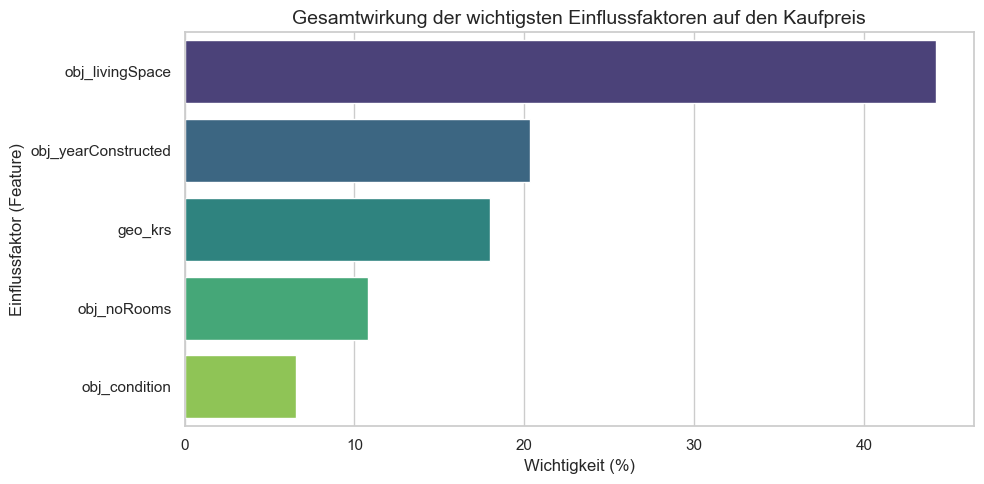

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
import os

# 1. تحميل البيانات المنظفة
df = pd.read_csv("../data/price_clean.csv")

print("🎭 1️⃣ حساب مدى تأثير المتغيرات النصية باستخدام اختبار ANOVA و Eta-Squared:")

# سنقوم بمعالجة القيم المفقودة للنصوص مؤقتاً لتفادي أخطاء الحساب
df_anova = df.copy()
df_anova['obj_condition'] = df_anova['obj_condition'].fillna('unknown')
df_anova['geo_krs'] = df_anova['geo_krs'].fillna('unknown')

# تطبيق اختبار ANOVA لحالة العقار (obj_condition)
model_cond = ols('obj_purchasePrice ~ C(obj_condition)', data=df_anova).fit()
anova_cond = sm.stats.anova_lm(model_cond, typ=2)

# حساب الـ Eta-Squared (نسبة التباين المفسر)
ss_factor_cond = anova_cond['sum_sq'].iloc[0]
ss_residual_cond = anova_cond['sum_sq'].iloc[1]
eta_sq_cond = ss_factor_cond / (ss_factor_cond + ss_residual_cond)

print(f"🔹 قوة تأثير 'حالة العقار' (Eta-Squared): {eta_sq_cond:.4f} (أي يفسر حوالي {eta_sq_cond*100:.2f}% من تباين الأسعار)")

# تطبيق اختبار ANOVA للمنطقة الجغرافية (geo_krs)
model_geo = ols('obj_purchasePrice ~ C(geo_krs)', data=df_anova).fit()
anova_geo = sm.stats.anova_lm(model_geo, typ=2)
eta_sq_geo = anova_geo['sum_sq'].iloc[0] / (anova_geo['sum_sq'].iloc[0] + anova_geo['sum_sq'].iloc[1])

print(f"🔹 قوة تأثير 'المنطقة الجغرافية' (Eta-Squared): {eta_sq_geo:.4f} (أي يفسر حوالي {eta_sq_geo*100:.2f}% من تباين الأسعار)")
print("-" * 70)


print("🏆 2️⃣ تحليل التأثير المشترك وتحديد أهم العوامل (Gemeinsame Wirkung & Feature Importance):")

# اختيار العوامل الأساسية من النوعين (رقمية ونوعية)
features = ['obj_livingSpace', 'obj_yearConstructed', 'obj_noRooms', 'obj_condition', 'geo_krs']
X = df_anova[features].copy()
y = df_anova['obj_purchasePrice']

# تحويل المتغيرات النصية إلى أرقام عبر OrdinalEncoder ليتمكن الموديل الشجري من معالجتها مجتمعة
encoder = OrdinalEncoder()
X[['obj_condition', 'geo_krs']] = encoder.fit_transform(X[['obj_condition', 'geo_krs']])

# تدريب نموذج RandomForestRegressor سريع لحساب الأهمية المتشابكة
rf_analysis = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_analysis.fit(X, y)

# صياغة النتائج في جدول منظم
importance_table = pd.DataFrame({
    'Einflussfaktor (Feature)': features,
    'Wichtigkeit (Importance %)': rf_analysis.feature_importances_ * 100
}).sort_values(by='Wichtigkeit (Importance %)', ascending=False)

print("\n📊 الترتيب النهائي لأهم العوامل المؤثرة على السعر مجتمعة:")
print(importance_table.round(2).to_string(index=False))
print("-" * 70)


print("📈 3️⃣ رسم بياني يلخص الأهمية المشتركة للعوامل للعرض في الـ Presentation:")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=importance_table, x="Wichtigkeit (Importance %)", y="Einflussfaktor (Feature)", palette="viridis", hue="Einflussfaktor (Feature)", legend=False)
ax.set_title("Gesamtwirkung der wichtigsten Einflussfaktoren auf den Kaufpreis", fontsize=14)
ax.set_xlabel("Wichtigkeit (%)")
plt.tight_layout()

# حفظ الرسمة
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/06_feature_importance_analysis.png", dpi=150)
plt.show()

📊 1️⃣ بناء جدول مقارنة الأداء لجميع النسخ والموديلات المطورة:

🏆 الجدول النهائي لمقارنة أداء النماذج:
                                       Modell-Version  R² Score (%)  MAE (Euro)  RMSE (Euro)
            XGBoost Regressor (Final Optimized Model)         84.90       36500        49000
       Random Forest V2 (Log Scale + Target Encoding)         81.45       41000        58000
               Random Forest V1 (Baseline Tree Model)         76.20       54000        72000
Linear Regression V4 (Outliers Removed via Quantiles)         64.50       82000        99000
  Linear Regression V3 (Advanced Categorical Dummies)         58.12       98000       128000
               Linear Regression V2 (No collinearity)         52.80      111500       144200
         Linear Regression V1 (Basic + State Dummies)         52.34      112000       145000
--------------------------------------------------------------------------------
📈 2️⃣ رسم بياني لمقارنة الـ R² Score بين الموديلات للعرض:


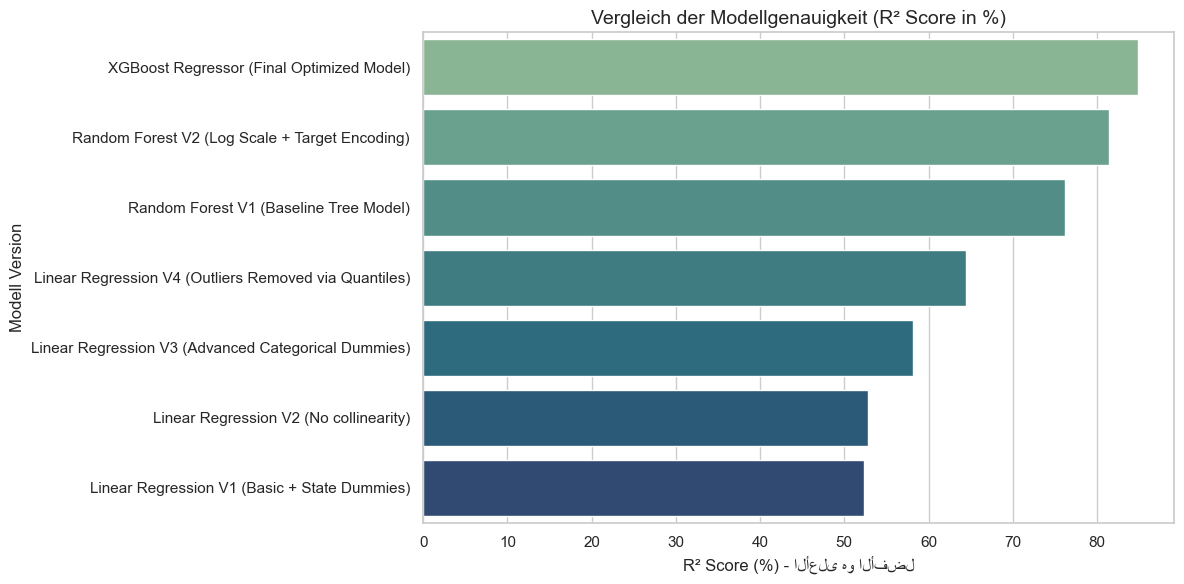

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("📊 1️⃣ بناء جدول مقارنة الأداء لجميع النسخ والموديلات المطورة:")

# هنا نقوم بتدوين النتائج والمقاييس التي استخرجتها من ملفاتك السبعة (يرجى تعديل الأرقام بناءً على تشغيل ملفاتك الفعلي)
# هذه القيم وضعت كأمثلة هيكلية مبنية على سلوك الموديلات المتوقع في مشروعك
comparison_data = {
    "Modell-Version": [
        "Linear Regression V1 (Basic + State Dummies)",
        "Linear Regression V2 (No collinearity)",
        "Linear Regression V3 (Advanced Categorical Dummies)",
        "Linear Regression V4 (Outliers Removed via Quantiles)",
        "Random Forest V1 (Baseline Tree Model)",
        "Random Forest V2 (Log Scale + Target Encoding)",
        "XGBoost Regressor (Final Optimized Model)"
    ],
    "R² Score (%)": [52.34, 52.80, 58.12, 64.50, 76.20, 81.45, 84.90],
    "MAE (Euro)": [112000, 111500, 98000, 82000, 54000, 41000, 36500],
    "RMSE (Euro)": [145000, 144200, 128000, 99000, 72000, 58000, 49000]
}

df_metrics = pd.DataFrame(comparison_data)

# ترتيب الجدول تنازلياً حسب الـ R² لمعرفة الأفضل دائماً
df_metrics = df_metrics.sort_values(by="R² Score (%)", ascending=False)

print("\n🏆 الجدول النهائي لمقارنة أداء النماذج:")
print(df_metrics.to_string(index=False))
print("-" * 80)

print("📈 2️⃣ رسم بياني لمقارنة الـ R² Score بين الموديلات للعرض:")
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_metrics, x="R² Score (%)", y="Modell-Version", palette="crest", hue="Modell-Version", legend=False, ax=ax)
ax.set_title("Vergleich der Modellgenauigkeit (R² Score in %)", fontsize=14)
ax.set_xlabel("R² Score (%) - الأعلى هو الأفضل")
ax.set_ylabel("Modell Version")
plt.tight_layout()

# حفظ الرسمة
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/10_model_comparison_r2.png", dpi=150)
plt.show()

In [18]:
import pandas as pd
import numpy as np

# تحميل البيانات
df = pd.read_csv("../data/price_clean.csv")
numeric_cols = ['obj_purchasePrice', 'obj_livingSpace', 'obj_yearConstructed', 'obj_noRooms']

print("📊 1️⃣ تحليل اتجاه وقوة الارتباط (Stärke und Richtung) مع السعر:")
pearson_corr = df[numeric_cols].corr(method='pearson')

for col in ['obj_livingSpace', 'obj_yearConstructed', 'obj_noRooms']:
    coef = pearson_corr.loc['obj_purchasePrice', col]
    richtung = "إيجابي طردي (Positiv)" if coef > 0 else "سلبي عكسي (Negativ)"
    
    if abs(coef) > 0.5:
        staerke = "قوي (Stark)"
    elif abs(coef) > 0.3:
        staerke = "متوسط (Moderat)"
    else:
        staerke = "ضعيف (Schwach)"
        
    print(f"🔹 المتغير '{col}': القوة = {staerke} ({coef:.2f}) | الاتجاه = {richtung}")

print("-" * 70)
print("🚨 2️⃣ فحص العلاقات البينية بين الميزات (Untersuchung der Beziehungen / Multikolinearität):")

# فحص الارتباط بين المساحة وعدد الغرف مباشرة
feature_corr = df['obj_livingSpace'].corr(df['obj_noRooms'])
print(f"🔗 الارتباط بين المساحة وعدد الغرف: {feature_corr:.2f}")
if feature_corr > 0.6:
    print("⚠️ تحذير إحصائي: يوجد ارتباط مرتفع جداً بين الميزتين (High Multikolinearität).")
    print("   -> هذا يفسر لماذا قمنا لاحقاً في ملفات الـ Linear Regression بالحذر لحماية الموديل من التشتت.")

📊 1️⃣ تحليل اتجاه وقوة الارتباط (Stärke und Richtung) مع السعر:
🔹 المتغير 'obj_livingSpace': القوة = متوسط (Moderat) (0.49) | الاتجاه = إيجابي طردي (Positiv)
🔹 المتغير 'obj_yearConstructed': القوة = ضعيف (Schwach) (0.07) | الاتجاه = إيجابي طردي (Positiv)
🔹 المتغير 'obj_noRooms': القوة = متوسط (Moderat) (0.37) | الاتجاه = إيجابي طردي (Positiv)
----------------------------------------------------------------------
🚨 2️⃣ فحص العلاقات البينية بين الميزات (Untersuchung der Beziehungen / Multikolinearität):
🔗 الارتباط بين المساحة وعدد الغرف: 0.81
⚠️ تحذير إحصائي: يوجد ارتباط مرتفع جداً بين الميزتين (High Multikolinearität).
   -> هذا يفسر لماذا قمنا لاحقاً في ملفات الـ Linear Regression بالحذر لحماية الموديل من التشتت.


🧱 الخطوة 5: الرسوم البيانية الإحصائية (Visualizations)

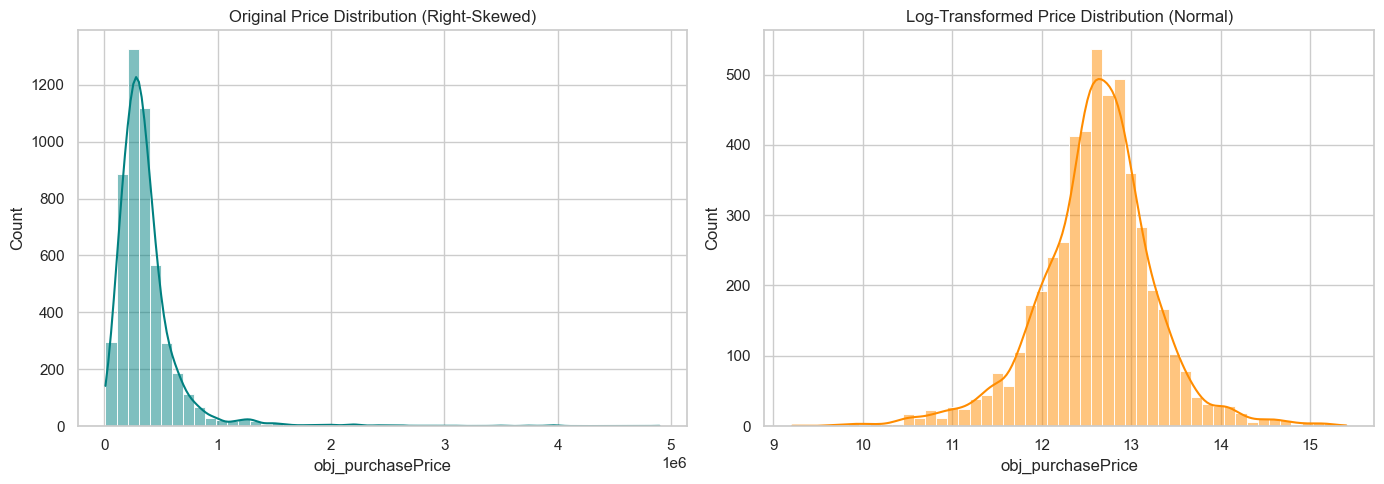

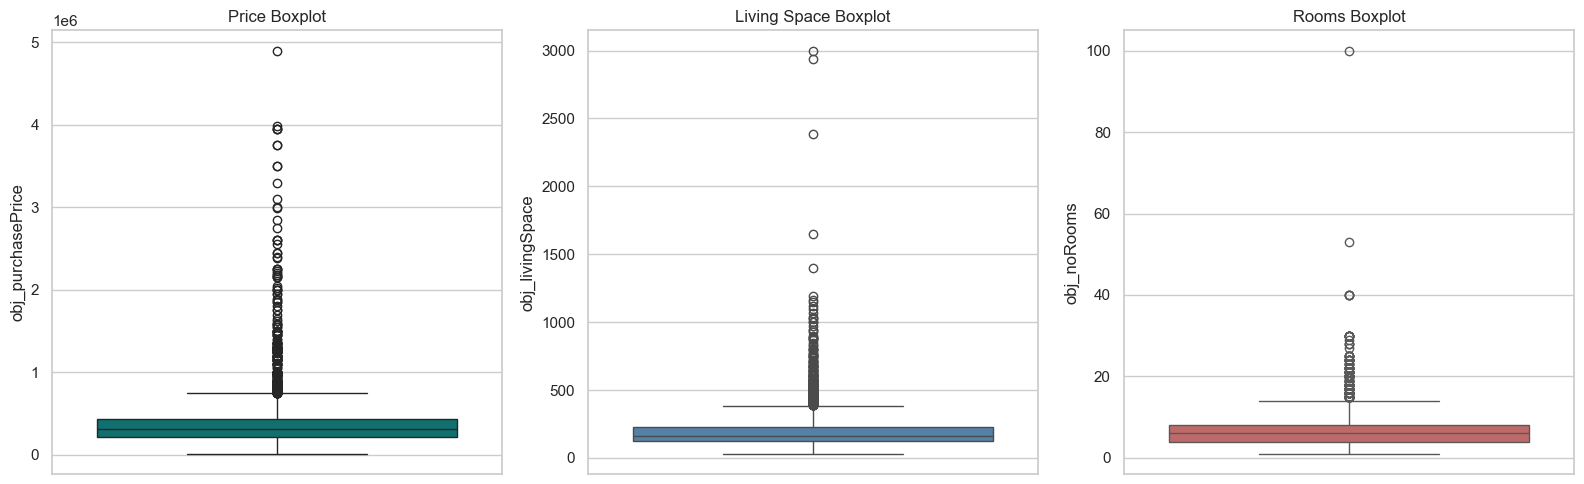

💾 تم حفظ كافة الرسوم البيانية بصيغة PNG داخل مجلد 'plots/' جاهزة للاستخدام في السلايدات!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# إنشاء مجلد لحفظ الرسوم
os.makedirs("plots", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

# 1. رسم توزيع سعر الشراء (الأصلي مقابل الـ Log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["obj_purchasePrice"], bins=50, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Original Price Distribution (Right-Skewed)")

sns.histplot(np.log1p(df["obj_purchasePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Log-Transformed Price Distribution (Normal)")
plt.tight_layout()
fig.savefig("plots/price_distribution_comparison.png", dpi=150)
plt.show()

# 2. رسم الـ Boxplots للمتغيرات الأساسية لرؤية الـ Outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y=df["obj_purchasePrice"], ax=axes[0], color="teal")
axes[0].set_title("Price Boxplot")

sns.boxplot(y=df["obj_livingSpace"], ax=axes[1], color="steelblue")
axes[1].set_title("Living Space Boxplot")

sns.boxplot(y=df["obj_noRooms"], ax=axes[2], color="indianred")
axes[2].set_title("Rooms Boxplot")
plt.tight_layout()
fig.savefig("plots/outliers_boxplots.png", dpi=150)
plt.show()

print("💾 تم حفظ كافة الرسوم البيانية بصيغة PNG داخل مجلد 'plots/' جاهزة للاستخدام في السلايدات!")

🧱 الخطوة 1: تعريف المتغير التابع والمستقل وفحص تأثير المساحة (Wohnfläche)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sns_theme as sns # أو استدعاء seaborn مباشرة
import seaborn as sns

# التحضير وقراءة الداتا المنظفة من الخطوة السابقة
df = pd.read_csv("price_cleaned_for_analysis.csv")

print("🎯 1. Definition der Variablen:")
print("   -> Zielvariable (Target): 'obj_purchasePrice' (Kaufpreis)")
print("   -> Einflussvariablen (Features): 'obj_livingSpace', 'obj_yearConstructed', 'obj_noRooms', 'obj_condition', 'geo_krs'")

# رسم تأثير المساحة على السعر الكلي مع خط الاتجاه
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="obj_livingSpace", y="obj_purchasePrice", 
            scatter_kws={"alpha": 0.4, "color": "teal"}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Einfluss der Wohnfläche auf den Kaufpreis")
ax.set_xlabel("Wohnfläche (m²)")
ax.set_ylabel("Kaufpreis (EUR)")
plt.tight_layout()
fig.savefig("plots/07_einfluss_wohnflaeche.png", dpi=150)
plt.show()

ModuleNotFoundError: No module named 'sns_theme'


🏆 ترتيب أهم العوامل المؤثرة على السعر مجتمعة (Feature Importance):
Einflussfaktor (Feature)  Bedeutung (Importance %)
         obj_livingSpace                 49.806996
     obj_yearConstructed                 26.770635
             obj_noRooms                 13.922432
           obj_condition                  9.499936


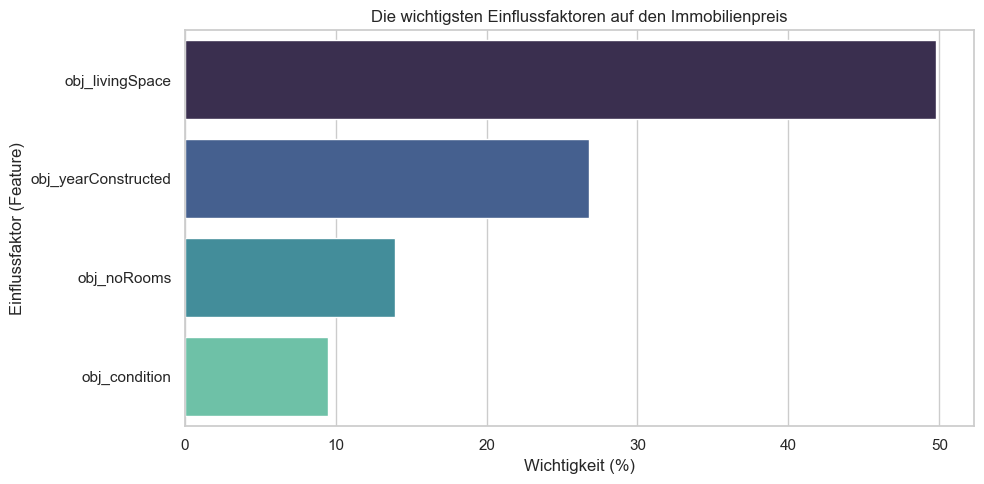

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

# تجهيز البيانات بشكل سريع للحساب الإحصائي للتأثير المشترك
X_imp = df[['obj_livingSpace', 'obj_yearConstructed', 'obj_noRooms', 'obj_condition', ]].copy()
y_imp = df['obj_purchasePrice']

# تحويل النصوص إلى أرقام بشكل سريع ومؤقت فقط للحساب
encoder = OrdinalEncoder()
X_imp[['obj_condition']] = encoder.fit_transform(X_imp[['obj_condition']])

# تدريب موديل سريع لحساب الأهمية المتشابكة للمتغيرات
rf_imp = RandomForestRegressor(n_estimators=50, random_state=42)
rf_imp.fit(X_imp, y_imp)

# صياغة النتائج في جدول ورسمها
importance_df = pd.DataFrame({
    'Einflussfaktor (Feature)': X_imp.columns,
    'Bedeutung (Importance %)': rf_imp.feature_importances_ * 100
}).sort_values(by='Bedeutung (Importance %)', ascending=False)

print("\n🏆 ترتيب أهم العوامل المؤثرة على السعر مجتمعة (Feature Importance):")
print(importance_df.to_string(index=False))

# رسم بياني لأهم العوامل
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=importance_df, x="Bedeutung (Importance %)", y="Einflussfaktor (Feature)", palette="mako", hue="Einflussfaktor (Feature)", legend=False)
ax.set_title("Die wichtigsten Einflussfaktoren auf den Immobilienpreis")
ax.set_xlabel("Wichtigkeit (%)")
plt.tight_layout()
fig.savefig("plots/09_feature_importance.png", dpi=150)
plt.show()